# Mitogenomes reveal timing in Beringian birds - bad mtDNA analysis

-----
| Name | Date | 
| - | - |
| Keiler Collier | 29 March 2026 |

## Background information
On 26 March 2026, George Sangster emailed Kevin Winker about reference-based contamination in the mtgenomes in my thesis Chapter 1.

Here, we will contain the code/analysis involved in finding where the errors in Brant Faircloth's pipeline (as followed by KCollier) came from.
Note that, because this dataset is relatively small, it is packaged within this notebook as the variable `RAW_CSV`.
This is to reduce potential errors when excel sheets are separated from their respective analysis files.

### Why visualize depth?

Mitogenomic assembly success is greatly affected by data coverage and quality, particularly in repetitive regions.
These, in turn, are affected by tissue type and preservation method, and are therefore highly variable across samples.
I don't have the tissue types (although I could get them from the flat file), but we should look at depth distribution

## Goals

1. Provide [raw data](#1-data-and-parameters)
2. Visualize the distribution of mitogenome coverages with a [violin plot](#2-violinplot-of-mtdna-coverage)
3. Provide [summary statistics](#3-summary-stats-of-mtdna-coverage) of mitogenome coverage
4. [Interpret](#4-interpretation-of-mtdna-coverage) mitogenome coverages

-----

## 1. Data and parameters

We define our parameter and raw data string.

$30$ is used as a threshold for high-coverage mitogenomes because it's the genome assembly literature's 'rule-of-thumb' value, at which we consider heterozygous calls to be reliable.

In [ ]:
threshold=30 
RAW_CSV = """
Species,Catalog,mtDNA Accession,Coverage,Taxon pair
Anser albifrons,UWBM43977,CSW4521,83.9,Anser
,UWBM43978,CSW4522,56.9,
,UWBM71170,SVD1426,94.6,
,UAM27372,JJW884,22.2,
,UAM30571,JJW1495,32.6,
,UAM35427,JJW2405,70.5,
,UAM35428,JJW2413,7.6,
,UAM34089,KSW4176,11.5,
Spatula clypeata,UWBM59827,CSW5794,3.6,Spatula
,UAM15459,DDG1988,3.6,
,UAM20167,DDG2053,17.2,
,UAM20152,DDG2054,13.2,
,UAM26717,SVD475,3.0,
,UAM36938,REW030,13.2,
,UAM36727,REW031,6.7,
,UAM15023,UAMX2539,7.1,
,UAM28973,UAMX5081,7.8,
Mareca penelope,UAM8758,DDG1663,156.3,Mareca
,UAM9759,DDG1703,129.5,
,UAM10008,DDG1716,167.2,
,UAM31321,DDG1768,243.0,
,UAM24301,UAMX4959,384.2,
,UAM24455,MJL037,343.0,
,UAM24550,UAMX5044,26.5,
,UAM27749,JJW968,633.9,
Mareca americana,UAM11919,JSW3039,411.0,Mareca
,UAM11908,KSW3028,595.9,
,UAM11909,KSW3029,214.1,
,UAM11916,KSW3036,404.6,
,UAM13141,UAMX1468,92.5,
,UAM26061,JJW383,177.4,
,UAM28087,JJW976,278.6,
,UAM28088,JJW948,72.4,
Anas platyrhynchos,UWBM47068,CSW4828,16.4,Anas p
,UWBM44374,JMB1220,36.7,
,UAM30399,KSW5390,5.0,
,UAM11328,DDG1776,23.9,
,UWBM47160,SAR6383,31.6,
,UAM28089,JJW943,89.9,
,UAM28074,JJW944,81.1,
,UAM29647,JJW1397,48.3,
,UAM30290,JJW1592,20.4,
,UAM30286,JJW1602,22.8,
,UAM11193,KGM007,127.2,
,UAM31321,UAMX5540,25.4,
Anas acuta,UWBM44114,DAB055,66.6,Anas acuta
,UAM22595,DDG2122,12.1,
,UAM28156,KSW5107,31.3,
,UAM28167,KSW5120,23.2,
,UAM30400,KSW5391,4.3,
,UAM31205,JJW1897,17.4,
,UAM23468,KGM895,48.3,
,UAM29039,REW548,22.8,
,UAM22113,REW601,9.8,
,UAM31335,UAMX5487,37.6,
Anas crecca,UAM22853,KSW4951,304.6,Anas crecca
,UAM11334,KGM021,142.1,
,UAM11335,KGM020,481.6,
,UAM14100,DDG1885,312.5,
,UAM14666,DDG1884,104.3,
,UAM9191,DDG1732,1282.9,
,UAM9255,DDG1704,459.4,
Anas carolinensis,UAM28444,UAMX5069,177.9,Anas crecca
,UAM11251,UAMX203,50.2,
,UAM20635,KSW4530,119.2,
,UAM11920,KSW3040,176.5,
,UAM14961,KGM335,320.8,
,UAM24497,JMM448,34.1,
,UAM28085,JJW978,76.0,
Aythya marila,UAM30395,KSW5385,24.8,Aythya
,UAM30394,KSW5393,8.7,
,UAM30392,KSW5394,2.6,
,UAM30396,KSW5395,2.3,
,UAM30393,KSW5396,7.2,
,UAM28067,JJW324,163.1,
,UAM18068,JJW325,111.9,
,UAM35653,REW611,127.3,
,UAM30915,UAMX5076,151.9,
,UAM29987,UAMX5077,183.8,
Somateria spectabilis,UWBM43965,CSW4509,211.9,Somateria s
,UWBM71169,SVD1425,33.9,
,UAM13153,ABJ107,30.0,
,UAM9396,UAMX892,27.1,
,UAM9422,UAMX901,16.4,
,UAM9423,UAMX903,3.0,
,UAM9439,UAMX907,13.9,
Somateria mollissima,UAM13721,UAMX1708,6.1,Somateria m
,UAM20085,DDG1939,22.7,
,UAM13336,DAR157,29.5,
,UAM26746,KGM912,37.2,
,UAM36436,KGM845,61.0,
,UAM9440,UAMX378,31.1,
,UAM35441,JJW2452,20.9,
,UAM37604,JJW2952,22.4,
,UAM34628,JJW2274,43.6,
,UAM34700,JJW2273,83.3,
Histrionicus histrionicus,UAM11800,DDG1753,19.0,Histrionicus
,UAM11799,DDG1754,22.0,
,UAM11801,DDG1755,1.9,
,UAM9600,KSW2979,2.3,
,UWBM82975,RYA1002,79.3,
,UWBM44446,SAR6074,40.8,
,UAM36431,JJW2664,2.2,
,UAM40488,JJW3694,2.0,
,UAM40489,JJW3695,1.3,
,UAM36745,KGM641,13.5,
Melanitta americana,UWBM43946,CSW4486,196.1,Melanitta
,UAM25996,JJW179,74.2,
,UAM27720,JJW951,14.5,
,UAM28065,JJW950,201.2,
,UAM29920,JJW1388,65.4,
,UAM35578,JJW2276,119.4,
Clangula hyemalis,UWBM43970,CSW4514,124.1,Clangula
,UWBM43919,CSW4454,264.4,
,UWBM43918,CSW4453,351.8,
,UWBM43917,CSW4452,407.5,
,UWBM43895,CSW4428,208.9,
,UWBM43894,CSW4427,209.9,
,UWBM43893,CSW4426,132.9,
,UAM29029,REW620,3382.7,
,UAM28184,REW619,295.8,
,UAM29027,REW618,251.0,
,UAM21883,REW583,250.2,
,UAM40387,REW564,141.8,
,UAM21931,REW532,437.8,
Mergus merganser merganser,UWBM43819,CSW4346,8.7,Mergus
,UAM25375,JJW063,3.9,
,UAM25991,JJW334,26.0,
,UAM25990,JJW335,4.9,
,UAM28042,JJW344,15.8,
,UAM27012,JJW762,16.3,
Mergus merganser americanus,UWBM9348,AEI105,2.8,Mergus
,UAM34366,JJW2298,30.4,
,UAM11037,UAMX1058,12.0,
,UAM24305,UAMX4957,6.4,
Lagopus lagopus koreni,UAM25139,KSW5046,63.2,Lagopus
,UAM28169,KSW5052,32.3,
,UAM29685,KSW5082,2.3,
,UAM28171,KSW5133,28.2,
,UAM14834,KSW5045,20.7,
Lagopus lagopus alascensis,UAM27018,JJW711,15.1,Lagopus
,UAM31562,JJW1970,21.5,
,UAM36927,JJW2909,15.2,
,UAM39209,JJW3352,9.0,
,UAM28238,TB349,32.0,
Pluvialis fulva,UAM13545,DDG1860,188.6,Pluvialis
,UAM26906,JJW145,228.6,
,UAM8798,KSW2383,68.3,
,UAM11307,TB408,188.3,
Pluvialis dominica,UAM26935,JJW362,137.0,Pluvialis
,UAM13181,KSW2402,233.9,
,UAM8938,KSW2468,169.0,
,UAM9511,TB235,395.1,
Numenius phaeopus variegatus,UWBM14228,TB1364,-,Numenius
,UAM14229,TB1116,193.5,
,UAM14230,TB1091,41.8,
,UAM14225,TB1023,222.9,
,UAM8212,DDF1666,266.7,
,UAM21379,CLP727,93.7,
,UAM14625,CLP450,371.5,
Numenius phaeopus hudsonicus,UAM11507,TB378,343.4,Numenius
,UAM13349,ABJ142,114.4,
,UAM9260,KSW2484,343.4,
,UAM13925,KGM036,120.9,
,UAM17980,JMM011,36.4,
,UAM28602,JJW1154,24.9,
,UAM28214,JJW1021,452.8,
,UAM28213,JJW1013,361.5,
Arenaria interpres,UAM14954,DAR268,20.0,Arenaria
,UAM26977,JJW676,112.8,
,UAM30797,JJW1637,178.8,
,UAM20220,JMM422,8.2,
,UAM13527,UAMX1744,76.7,
Arenaria melanocephala,UAM28748,JJW1153,5.0,Arenaria
,UAM40266,JJW3588,449.8,
,UAM20142,JMM326,141.0,
,UAM20098,JMM327,18.0,
Calidris alpina arcticola,UAM25341,JJW4409,18.9,Calidris
,UAM19815,JJW4411,3.3,
,UAM20132,UAMX3267,26.7,
Calidris alpina pacifica,UAM26914,JJW015,14.8,Calidris
,UAM26913,JJW016,249.0,
,UAM27576,JJW704,22.2,
,UAM30313,JJW1490,21.7,
,UAM30879,JJW1821,54.7,
Gallinago gallinago,UAM21848,CLP713,9.8,Gallinago
,UAM8228,DDG1650,1.8,
,UAM26800,JJW158,1.5,
,UAM24695,KSW5126,33.9,
,UAM28175,KSW5134,1.9,
Gallinago delicata,UAM19231,DDG2021,2.2,Gallinago
,UAM15063,DDG1945,2.1,
,UAM20505,DDG2035,55.0,
,UAM22570,DDG2118,31.9,
,UAM30488,JJW1536,1.6,
Tringa brevipes,UAM8805,KSW1782,897.6,Tringa bi
,UAM8521,KSW1781,399.3,
,UAM7534,KSW1780,167.3,
,UAM28428,JJW1030,163.0,
,UAM28427,JJW906,227.9,
,UAM10112,DDG1736,231.6,
,UAM28430,JJW1061,146.5,
,UAM28429,JJW1062,20.6,
Tringa incana,UAM13434,DAR228,12.8,Tringa bi
,UAM28422,JJW720,160.4,
,UAM28425,JJW724,76.2,
,UAM28426,JJW1022,218.7,
,UAM8240,KSW1778,413.4,
,UAM21813,KSW3378,119.6,
,UAM24859,UAMX1645,126.2,
,UAM13569,UAMX1735,184.7,
Tringa nebularia,UAM8282,DDG1686,2.1,Tringa nm
,UAM14119,DDG1916,27.1,
,UAM17482,DDG1990,2.0,
,UAM22850,KSW4958,2.8,
,UAM24570,UAMX4620,28.8,
Tringa melanoleuca,UAM30489,JJW1663,2.0,Tringa nm
,UAM18023,JMM014,15.3,
,UAM20143,JMM340,75.3,
,UAM13578,UAMX1941,6.8,
,UAM27573,UAMX5119,12.3,
Uria aalge inornata,UWBM44407,JMB994,6.8,Uria a
,UWBM4408,JMB995,9.6,
,UWBM44409,JMB996,10.7,
,UWBM44410,JMB997,15.0,
,UWBM44411,JMB998,16.1,
,UAM7729,KSW1629,19.2,
,UAM10687,KSW1631,9.9,
,UAM10688,KSW1632,18.3,
,UAM10689,KSW1633,5.5,
,UAM10690,KSW1634,11.3,
Uria lomvia arra,UWBM55300,BKS351,11.0,Uria l
,UWBM55725,JMB857,11.4,
,UWBM44177,JMB1001,16.9,
,UWBM44178,JMB1002,17.8,
,UWBM72702,NCSM17754,7.2,
,UAM30510,JJW1509,2.6,
,UAM30511,JJW1510,6.2,
,UAM9608,UAMX387,5.8,
,UAM13445,UAMX1553,8.1,
,UAM20236,UAMX3290,7.0,
Larus canus kamtschatschensis,UAM22926,KSW4989,15.5,Larus c
,UAM22863,KSW4959,269.6,
,UAM37770,JJW3012,2.7,
,UAM13377,DDG1876,20.6,
,UAM11014,DDG1771,2.7,
Larus brachyrhynchus,UAM24812,UAMX4789,3.0,Larus c
,UAM36875,JJW2921,90.0,
,UAM26901,JJW010,5.0,
,UAM14803,DDG1922,9.8,
,UAM14682,DDG1921,1.2,
Larus argentatus vegae,UAM28162,KSW5090,67.2,Larus a
,UAM26660,KSW5044,84.5,
,UAM25987,JJW224,1.4,
,UAM25984,JJW257,13.1,
,UAM25983,JJW343,1.9,
Larus argentatus smithsonianus,UAM35755,JJW2547,19.8,Larus a
,UAM35754,JJW2548,28.1,
,UAM35753,JJW2549,2.5,
,UAM35751,JJW2551,2.6,
,UAM30575,JJW1533,6.8,
Leucosticte hyperboreus,UWBM43852,CSW4379,5.0,Leucosticte
,UWBM43851,CSW4378,5.4,
,UWBM43982,CSW4526,10.7,
,UAM28158,KSW5035,9.5,
,UAM28160,KSW5108,24.3,
,UAM40190,JJW3585,1.3,
,UAM40191,JJW3586,13.4,
,UAM9257,KSW2490,8.3,
,UAM8929,UAMX683,28.6,
,UAM24327,UAMX4940,2.1,
Gavia stellata,UWBM43925,CSW4461,14.1,Gavia
,UWBM44122,DAB063,-,
,UWBM44259,JMB1098,9.3,
,UWBM44260,JMB1099,2.9,
,UWBM44653,SAR6293,3.2,
,UAM13601,DAR275,4.5,
,UAM40094,JJW3574,41.0,
,UAM20711,KGM628,30.2,
,UAM38314,UAMX3952,67.4,
,UAM40093,UAMX6608,44.7,
Picoides tridactylus,UWBM44422,SAR6046,10.4,Picoides
,UWBM52660,SVD144,5.7,
,UAM17739,TB1448,8.7,
Picoides dorsalis fasciatus,UAM31832,JJW2059,26.5,Picoides
,UAM36600,JJW2842,19.8,
,UAM38328,JJW3139,55.3,
,UAM8580,UAMX503,21.4,
,UAM20114,UAMX3273,38.7,
Pica pica,UWBM74697,UWBM74697,161.3,Pica
,UWBM74569,UWBM74569,87.8,
,UWBM72091,UWBM72091,1.7,
,UWBM72084,UWBM72084,69.4,
,UWBM47197,UWBM47197,79.4,
,UWBM44585,UWBM44585,158.1,
,UWBM44584,UWBM44584,42.3,
,UWBM44581,UWBM44581,19.3,
Pica hudsonia,UAM10105,UAMX953,6.8,Pica
,UAM8511,KSW2704,219.3,
,UAM27024,JJW683,139.3,
,UAM17742,CLP245,31.0,
,UAM13052,CLP219,71.8,
,UAM13053,CLP218,160.0,
,UAM12453,CLP208,96.3,
Corvus corax,UWBM46861,BKS908,3.3,Corvus
,UWBM56544,BKS3241,1.5,
,UWBM57899,BKS4041,2.6,
,UWBM57909,BKS4052,5.3,
,UWBM71244,SVD231a,2.2,
,UWBM59566,SVD1398,9.0,
,UAM17737,TB1445,2.6,
,UAM10021,DDG1749,5.5,
,UAM38000,JJW2991,48.3,
,UAM39709,JJW3401,58.2,
,UAM41600,JJW4373,3.2,
,UAM17761,JMM133,4.2,
,UAM8803,KSW2715,8.1,
,UAM22252,KSW4763,9.8,
,UAM15040,RWD26009,4.4,
,UAM9313,UAMX844,9.8,
,UAM11113,UAMX1061,5.5,
Phylloscopus examinandus,UAM17665,DDG1991,6.2,Phylloscopus
,UAM29472,KSW5250,1.6,
,UAM30464,KSW5336,11.3,
,UAM30462,KSW5354,13.1,
,UAM30461,KSW5373,5.5,
Phylloscopus borealis borealis,UWBM43818,CSW4345,19.7,Phylloscopus
,UWBM44417,SAR6041,14.6,
,UWBM44418,SAR6042,11.6,
,UWBM82284,SVD2977,3.9,
,UWBM82285,SVD2978,21.1,
Phylloscopus borealis kennicotti,UAM34615,JJW2241,47.2,Phylloscopus
,UAM36347,JJW2649,17.3,
,UAM20149,JMM337,47.3,
,UAM20150,JMM338,15.8,
,UAM7372,KSW1456,3.8,
Luscinia svecica,UWBM44489,SAR6270,-,Luscinia
,UWBM44629,SAR6269,1138.0,
,UWBM44363,JMB1208,-,
,UWBM44362,JMB1207,1.9,
,UWBM44361,JMB1206,121.8,
,UWBM44246,JMB1082,113.9,
,UWBM44242,JMB1278,225.2,
,UWBM44233,JMB1064,128.3,
,UAM13718,ABJ200,235.8,
,UAM15419,MJM048,58.7,
,UAM17727,MJM047,123.4,
,UAM8944,KSW2481,50.6,
,UAM8584,KSW2409,279.8,
,UAM8945,KSW2408,49.6,
,UAM8946,KSW2407,-,
,UAM8585,KSW2406,133.3,
Motacilla tschutschensis tschutschensis,UAM13402,ABJ133,10.6,Motacilla
,UAM15178,DDG1935,36.3,
,UAM27366,JJW216,21.9,
,UAM27364,JJW520,7.7,
,UAM28177,JJW629,26.3,
Motacilla tschutschensis simillima,UAM14353,ABJ179,11.8,Motacilla
,UAM28715,JJW1179,2.2,
,UAM28717,JJW1185,5.4,
,UAM29362,JJW1317,13.3,
,UAM19448,MJM122,5.1,
Anthus rubescens japonicus,UAM13353,DDG1877,3.2,Anthus
,UAM27351,JJW864,25.3,
,UAM28057,JJW905,246.9,
,UAM39615,JJW3455,258.3,
,UAM15068,KSW3980,15.4,
Anthus rubescens pacificus,UAM11452,CLP200,33.3,Anthus
,UAM31927,JJW2045,1.7,
,UAM31928,JJW2046,15.5,
,UAM19419,MJM037,13.2,
,UAM13540,RWD25949,4.3,
Pinicola enucleator kamtschatschensis,UWBM51643,SVD423,172.5,Pinicola
,UWBM51627,SVD407,139.4,
,UWBM47315,SAR6539,53.1,
,UWBM47314,SAR6538,1535.1,
,UAM24602,DDG2190,396.8,
,UAM24601,DDG2189,225.2,
Pinicola enucleator flammula,UAM10158,UAMX1014,1146.7,Pinicola
,UAM8794,KSW1695,116.5,
,UAM8797,KSW1694,432.4,
,UAM28530,JJW1097,297.8,
,UAM26361,JJW030,245.3,
,UAM11286,ABJ012,105.1,
,UAM11285,ABJ011,56.2,
Leucosticte arctoa,UWBM44077,CSW4675,3.3,Leucosticte
,UWBM44366,JMB1211,3.7,
,UWBM44622,SAR6262,3.5,
,UWBM44623,SAR6263,5.1,
,UWBM44624,SAR6264,6.2,
Leucosticte tephrocotis griseonucha,UAM10981,DDG1750,12.6,Leucosticte
,UAM31438,RWD24852,17.2,
,UAM31439,RWD24857,367.0,
,UAM24603,UAMX5158,6.7,
,UAM24607,UAMX5168,13.7,
Leucosticte tephrocotis littoralis,UAM28707,JJW1163,14.5,Leucosticte
,UAM40954,JJW3809,39.2,
,UAM40957,JJW3812,83.6,
,UAM40959,JJW3814,13.7,
,UAM40961,JJW3816,66.5,
Leucosticte tephrocotis tephrocotis,UAM27288,JJW873,32.6,Leucosticte
,UAM35600,JJW2460,33.5,
,UAM35598,JJW2465,31.7,
,UAM38654,JJW3204,87.5,
Leucosticte tephrocotis umbrina,UAM28620,AF14344,12.6,Leucosticte
,UAM28619,AF14346,2.3,
,FMNH34305,AF14351,10.1,
,UAM7351,KSW1646,2.1,
,UAM17748,UAMX2921,37.6,
Calcarius lapponicus coloratus,UAM29827,UAM29827,8.5,Calcarius
,UAM29825,UAM29825,25.6,
Calcarius lapponicus alascensis,UAM13337,RWD25944,9.4,Calcarius
,UAM7653,KSW1821,4.1,
,UAM19614,CLP051,12.3,
,UAM9525,CLP048,40.0,
,UAM9407,CLP038,74.8,
Plectrophenax nivalis,UAM11856,CLP163,240.1,Plectrophenax
,UAM27725,JJW292,261.6,
,UAM8476,KSW2690,169.6,
,UAM8474,KSW2691,392.6,
Plectropomus hyperboreus,UAM7407,KSW1588,8.0,Plectrophenax
,UAM7066,KSW1610,98.3,
,UAM7524,KSW1611,19.7,
,UAM8200,KSW1617,113.8,
"""


-----

## 2. Violinplot of mtDNA coverage

This is a [violinplot](https://seaborn.pydata.org/generated/seaborn.violinplot.html) of coverage, with a threshold line at $30$ x coverage.

The raw data is derived from "Table S3. Mitogenome coverage depths per individual specimen. Institution abbreviations are UAM for the University of Alaska Museum and UWBM for the University of Washington Burke Museum."

In [90]:
import io

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Each row must match the header column count (Species, Catalog, accession, Coverage, Taxon pair). A short header mis-parses the file and can trigger seaborn/pandas "duplicate labels" reindex errors.
df = pd.read_csv(io.StringIO(RAW_CSV))
df["Species"] = df["Species"].ffill()
df["Taxon pair"] = df["Taxon pair"].ffill()
df["Coverage"] = pd.to_numeric(df["Coverage"], errors="coerce")

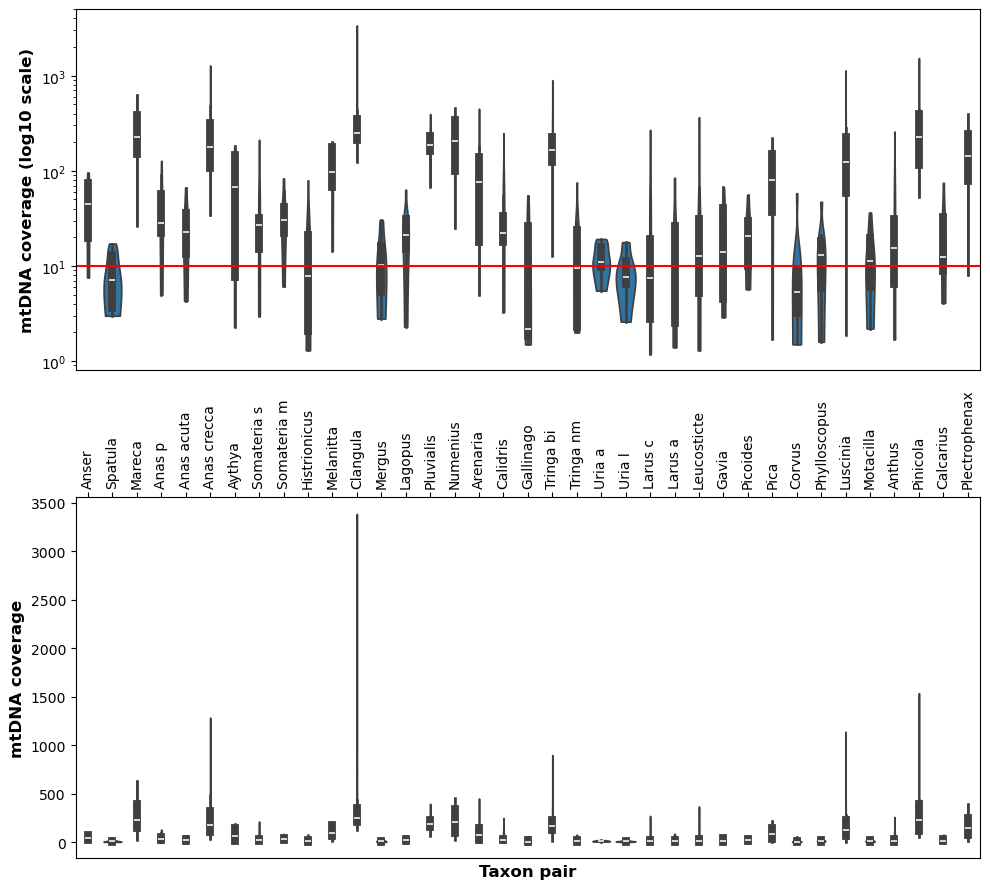

In [91]:
fig, (ax_log, ax_lin) = plt.subplots(2, 1, figsize=(10, 9), sharex=True, gridspec_kw={"height_ratios": [1, 1]})
sns.violinplot(data=df, x="Taxon pair", y="Coverage", ax=ax_log, inner="box", cut=0)
ax_log.set_yscale("log")
ax_log.set_ylabel("mtDNA coverage (log10 scale)", fontsize=12, fontweight="bold")

ax_log.set_xlabel("")
ax_log.axhline(y=10, color='r', linestyle='-')
ax_log.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False, labeltop=False)

sns.violinplot(data=df, x="Taxon pair", y="Coverage", ax=ax_lin, inner="box", cut=0)
ax_lin.set_ylabel("mtDNA coverage", fontsize=12, fontweight="bold")
# Category names on the top spine of the lower panel (between log and linear axes).
ax_lin.xaxis.tick_top()
ax_lin.tick_params(
    axis="x",
    rotation=90,
    bottom=False,
    labelbottom=False,
    top=True,
    labeltop=True,
)
ax_lin.set_xlabel("Taxon pair", fontsize=12, fontweight="bold")
ax_lin.xaxis.set_label_position("bottom")
plt.tight_layout()
plt.show()

## 3. Summary stats of mtdna coverage

In [93]:
sumstats = df.groupby("Taxon pair")["Coverage"].describe()
print(sumstats)

               count        mean         std    min      25%     50%      75%  \
Taxon pair                                                                      
Anas acuta      10.0   27.340000   19.174416    4.3   13.425   23.00   36.025   
Anas crecca     14.0  288.721429  320.176339   34.1  108.025  177.20  318.725   
Anas p          12.0   44.058333   36.519097    5.0   22.200   28.50   56.500   
Anser            8.0   47.475000   33.617247    7.6   19.525   44.75   73.850   
Anthus          10.0   61.710000  101.121219    1.7    6.525   15.45   31.300   
Arenaria         9.0  112.255556  141.501618    5.0   18.000   76.70  141.000   
Aythya          10.0   78.360000   75.672014    2.3    7.575   68.35  145.750   
Calcarius        7.0   24.957143   25.229272    4.1    8.950   12.30   32.800   
Calidris         8.0   51.412500   81.161997    3.3   17.875   21.95   33.700   
Clangula        13.0  496.830769  872.691754  124.1  208.900  251.00  351.800   
Corvus          17.0   10.79

In [94]:
df.describe()

,Coverage
count,419.000000
mean,101.568019
std,231.844413
min,1.200000
25%,8.700000
50%,26.300000
75%,120.250000
max,3382.700000


## 4. Interpretation of mtDNA coverage

Our mitogenome coverage values are spread over 4 orders of magnitude, with an overall average of $419.00\pm 231.8$ x.
However, this universal mean is misleading: it is driven by a small number of high-coverage lineages and individuals - most notably the *Clangula* taxon-pair, which averages $496.83 \pm 872.69$.
(I did not explicitly test for differences among lineages, but visually, taxon-pair clearly affects the average mitogenomic coverage.)

More problematically, $\frac{221}{424}$ ($52\%$) mitogenomes and $\frac{17}{39}$ ($43\%$ ) taxon-pairs used in this paper were under 30x coverage.
These would be **considered low-coverage** in modern de-novo assembly efforts.

As such, large portions of the dataset could be reasonably expected to be susceptible to reference contamination.

In [100]:
taxa_below_x=sumstats[sumstats["mean"] <= threshold]
num_under_xcov=len(df[df["Coverage"] <= threshold])
percent_under_xcov=num_under_xcov/len(df)*100

print(f"{num_under_xcov} ({percent_under_xcov:.2f}%) of our individual mitogenomes are below {threshold}x coverage.")

print(f"{len(taxa_below_x)} ({len(taxa_below_x)/39*100:.2f}%) taxon pairs have average values below {threshold}x coverage:")
for taxon, row in taxa_below_x.iterrows():
    std_disp = f"{row['std']:.2f}" if pd.notna(row["std"]) else "n/a"
    print(f"  {taxon}: {row['mean']:.2f} ± {std_disp}")


221 (52.12%) of our individual mitogenomes are below 30x coverage.
17 (43.59%) taxon pairs have average values below 30x coverage:
  Anas acuta: 27.34 ± 19.17
  Calcarius: 24.96 ± 25.23
  Corvus: 10.79 ± 16.29
  Gallinago: 14.17 ± 19.15
  Gavia: 24.14 ± 22.94
  Histrionicus: 18.43 ± 24.95
  Lagopus: 23.95 ± 16.86
  Larus a: 22.79 ± 29.59
  Leucosticte: 29.86 ± 63.48
  Mergus: 12.72 ± 9.46
  Motacilla: 14.06 ± 10.85
  Phylloscopus: 16.00 ± 14.03
  Picoides: 23.31 ± 16.80
  Spatula: 8.38 ± 5.05
  Tringa nm: 17.45 ± 22.71
  Uria a: 12.24 ± 4.70
  Uria l: 9.40 ± 4.89
